First 5 records:
                               tooth_img_name  tooth_number target_class  \
nh1ZWZC_-h  HONILNO-lower-390_nh1ZWZC_-h.jpg            47          no_   
dSAFgQIhsC  HONILNO-lower-390_dSAFgQIhsC.jpg            46          no_   
YyKkMc76si  HONILNO-lower-390_YyKkMc76si.jpg            45          no_   
wsU7OWGjqT  HONILNO-lower-390_wsU7OWGjqT.jpg            44          no_   
hQ8fP9yWPJ  HONILNO-lower-390_hQ8fP9yWPJ.jpg            43          no_   

                                                   tooth_poly  
nh1ZWZC_-h  {'all_points_x': [126, 125, 123, 122, 120, 119...  
dSAFgQIhsC  {'all_points_x': [161, 160, 158, 157, 155, 154...  
YyKkMc76si  {'all_points_x': [179, 178, 174, 173, 169, 168...  
wsU7OWGjqT  {'all_points_x': [135, 134, 125, 124, 116, 115...  
hQ8fP9yWPJ  {'all_points_x': [83, 82, 81, 80, 79, 78, 77, ...  

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 10017 entries, nh1ZWZC_-h to MpA8Pz_Sq1
Data columns (total 4 columns):
 #   Column  

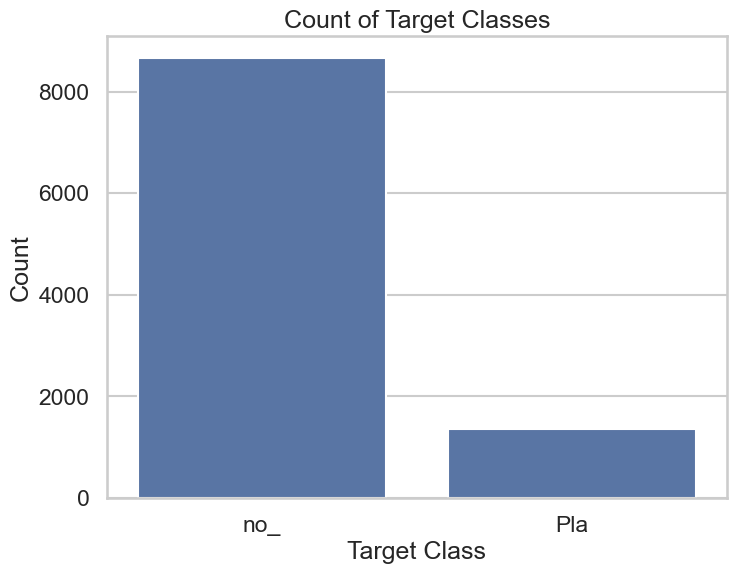

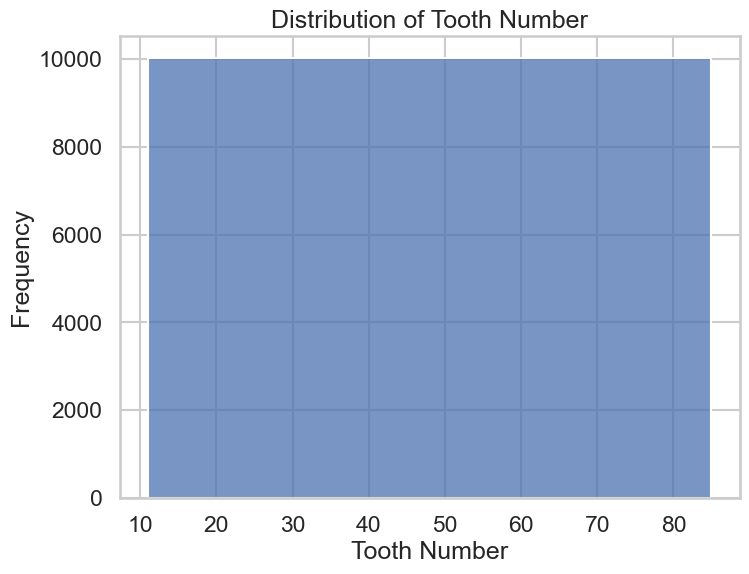

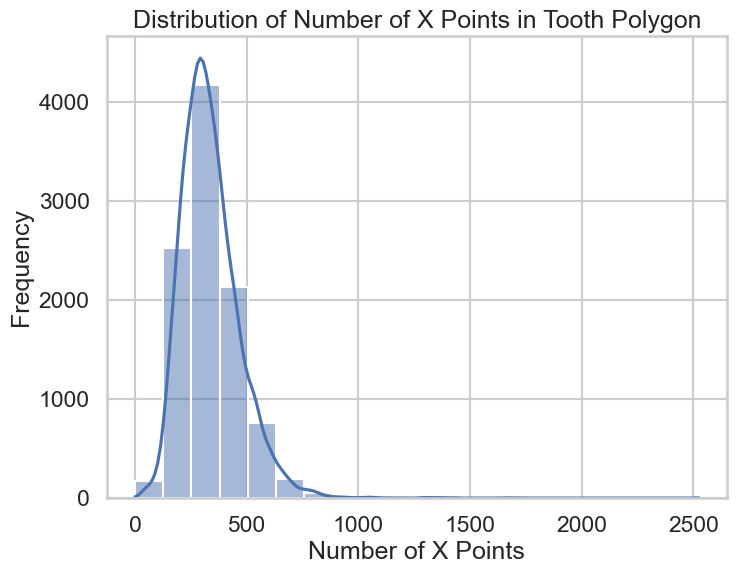

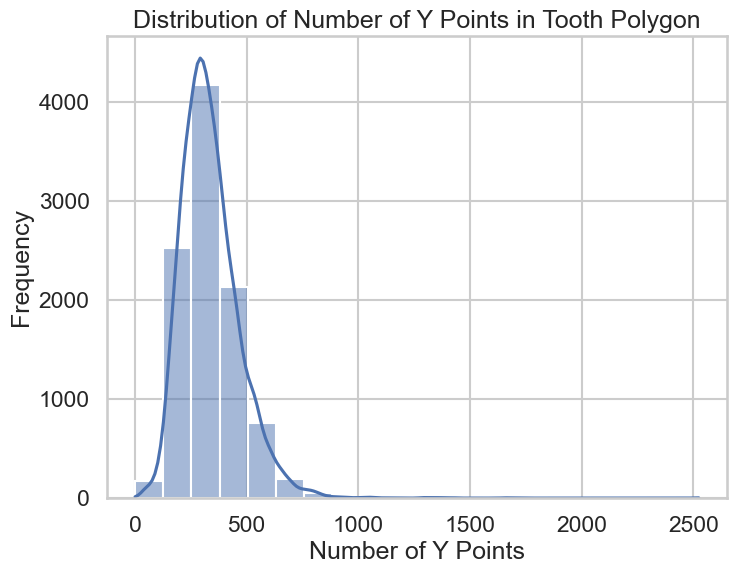


Summary of tooth_number by target_class:
               count       mean        std   min   25%   50%   75%   max
target_class                                                            
Pla           1359.0  28.999264  11.827460  11.0  21.0  31.0  41.0  85.0
no_           8658.0  29.403904  11.672174  11.0  21.0  31.0  41.0  85.0


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Increase plot resolution
sns.set(style="whitegrid", context="talk")

# Load the JSON file
annot_path = 'C:/Users/anedaeij23/Project/tooth_classification_project/data/processed/filtered_Pla_annotations.json'
with open(annot_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Convert the dictionary into a DataFrame.
# Top‑level keys become the index and the values become rows.
df = pd.DataFrame.from_dict(data, orient='index')



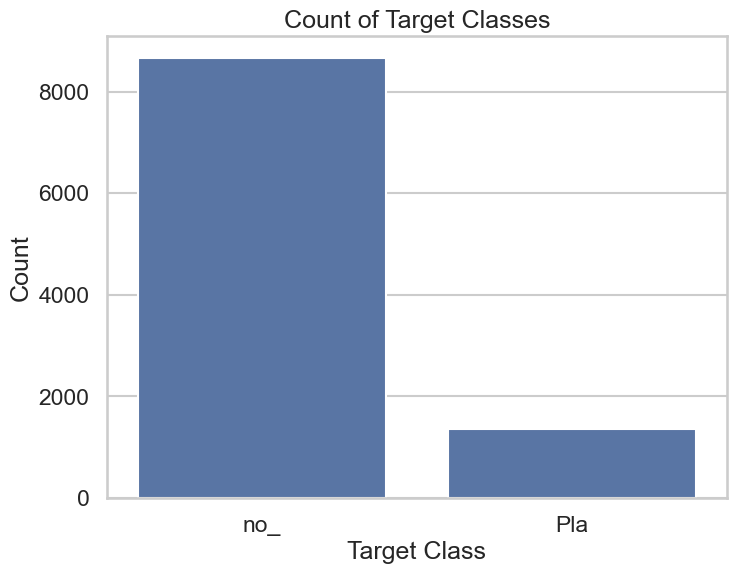

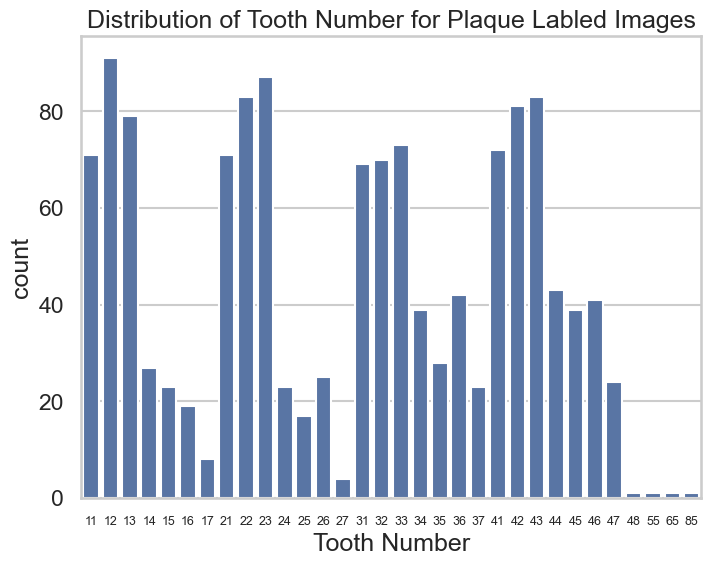

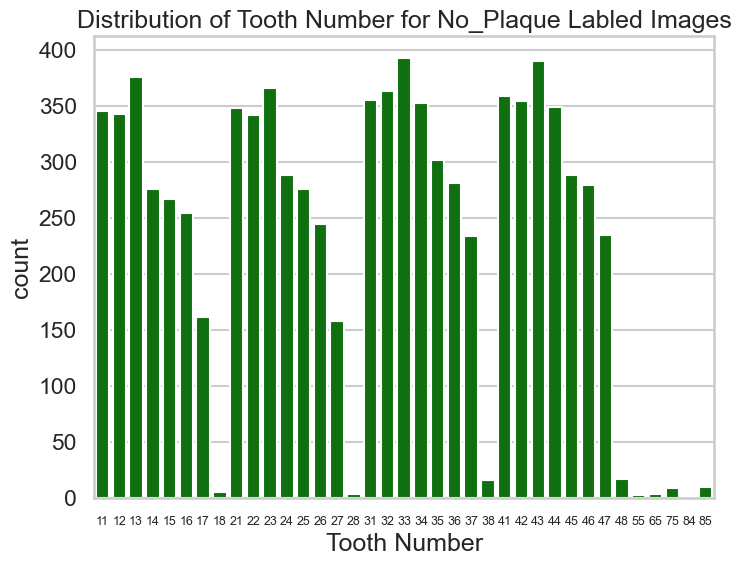

In [11]:

# Plot distribution of the target class column
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='target_class', order=df['target_class'].value_counts().index)
plt.title('Count of Target Classes')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

# Plot distribution of tooth numbers (if numeric)
plt.figure(figsize=(8, 6))
sns.countplot(data=df[df['target_class']== "Pla"], x='tooth_number')
plt.title('Distribution of Tooth Number for Plaque Labled Images')
plt.xlabel('Tooth Number')
plt.ylabel('count')
plt.xticks( size=9)
plt.show()

# Plot distribution of tooth numbers (if numeric)
plt.figure(figsize=(8, 6))
sns.countplot(data=df[df['target_class']== "no_"], x='tooth_number', color='green')
plt.title('Distribution of Tooth Number for No_Plaque Labled Images')
plt.xlabel('Tooth Number')
plt.ylabel('count')
plt.xticks( size=9)
plt.show()


preprocessing ideas:
1. remove images with small visible tooth areas
2. Augment only teeth with plaque
3. 

# complete json

In [122]:
path= 'C:/Users/anedaeij23/Project/tooth_classification_project/data/intrim/filtered_Pla_annotations.json'

In [123]:
import json
from collections import Counter, defaultdict

# Replace 'data.json' with the path to your JSON file
with open(path, 'r') as f:
    data = json.load(f)

# Counter for the overall number of each class
class_counts = Counter()

# Dictionary to hold the distribution of classes per tooth number
# Keys are tooth numbers and values are counters of target classes for that tooth
tooth_class_distribution = defaultdict(Counter)

# Iterate over each record in the JSON data
for record in data.values():
    target_class = record.get('target_class')
    tooth_number = record.get('tooth_number')
    
    if target_class:
        class_counts[target_class] += 1
        
        if tooth_number is not None:
            tooth_class_distribution[tooth_number][target_class] += 1

# Print the overall counts for each class
print("Overall class counts:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

# Print the distribution of classes per tooth number
print("\nDistribution of classes in tooth numbers:")
for tooth, counts in sorted(tooth_class_distribution.items()):
    print(f"Tooth number {tooth}: {dict(counts)}")


Overall class counts:
no_: 8658
Pla: 1359

Distribution of classes in tooth numbers:
Tooth number 11: {'no_': 346, 'Pla': 71}
Tooth number 12: {'no_': 343, 'Pla': 91}
Tooth number 13: {'no_': 376, 'Pla': 79}
Tooth number 14: {'no_': 276, 'Pla': 27}
Tooth number 15: {'no_': 267, 'Pla': 23}
Tooth number 16: {'no_': 255, 'Pla': 19}
Tooth number 17: {'no_': 162, 'Pla': 8}
Tooth number 18: {'no_': 5}
Tooth number 21: {'no_': 348, 'Pla': 71}
Tooth number 22: {'no_': 342, 'Pla': 83}
Tooth number 23: {'no_': 366, 'Pla': 87}
Tooth number 24: {'no_': 289, 'Pla': 23}
Tooth number 25: {'no_': 276, 'Pla': 17}
Tooth number 26: {'no_': 245, 'Pla': 25}
Tooth number 27: {'no_': 158, 'Pla': 4}
Tooth number 28: {'no_': 4}
Tooth number 31: {'no_': 356, 'Pla': 69}
Tooth number 32: {'no_': 364, 'Pla': 70}
Tooth number 33: {'no_': 393, 'Pla': 73}
Tooth number 34: {'no_': 353, 'Pla': 39}
Tooth number 35: {'no_': 302, 'Pla': 28}
Tooth number 36: {'no_': 281, 'Pla': 42}
Tooth number 37: {'no_': 234, 'Pla': 23}


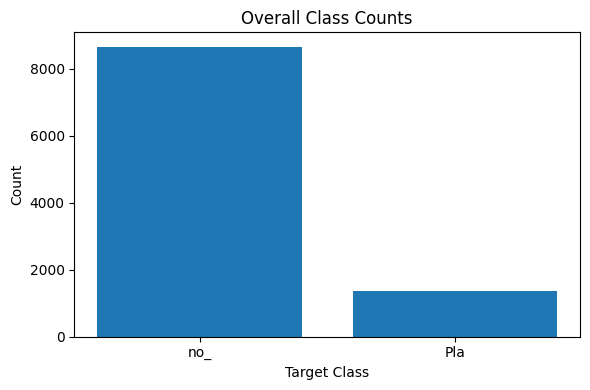

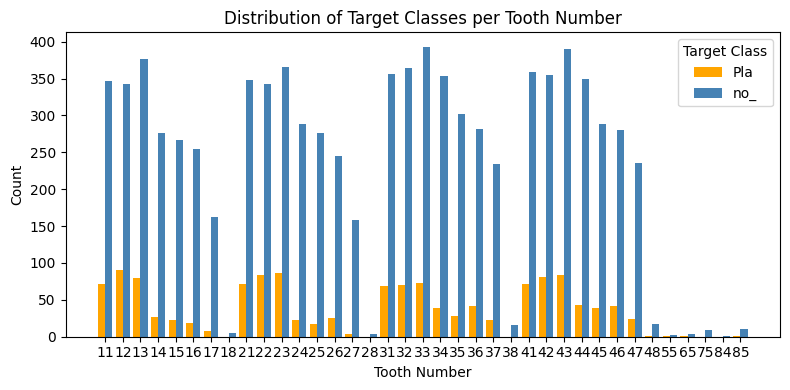

In [133]:
import json
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

# Replace 'data.json' with the path to your JSON file.
with open(path, 'r') as f:
    data = json.load(f)

# Compute overall class counts and distribution per tooth number.
class_counts = Counter()
tooth_class_distribution = defaultdict(Counter)

for record in data.values():
    target_class = record.get('target_class')
    tooth_number = record.get('tooth_number')
    if target_class:
        class_counts[target_class] += 1
        if tooth_number is not None:
            tooth_class_distribution[tooth_number][target_class] += 1

# Figure 1: Bar chart for overall class counts.
plt.figure(figsize=(6, 4))
classes = list(class_counts.keys())
counts = list(class_counts.values())
plt.bar(classes, counts)
plt.title("Overall Class Counts")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Figure 2: Grouped bar chart for distribution of classes per tooth number.
# Prepare the data.
tooth_numbers = sorted(tooth_class_distribution.keys())
# Determine the list of unique classes present.
unique_classes = sorted({cls for counts in tooth_class_distribution.values() for cls in counts})

# Create a dictionary: for each class, a list of counts corresponding to each tooth number.
counts_per_class = {
    cls: [tooth_class_distribution[tooth].get(cls, 0) for tooth in tooth_numbers]
    for cls in unique_classes
}

# Define bar positions.
x = np.arange(len(tooth_numbers))  # positions for tooth numbers
width = 0.8 / len(unique_classes)    # width of each bar (grouped)

plt.figure(figsize=(8, 4))
# Plot bars for each class.
for i, cls in enumerate(unique_classes):
    color = 'orange' if cls == 'Pla' else 'steelblue'  # Example color mapping
    plt.bar(x + i * width, counts_per_class[cls], width=width, label=cls, color=color)

plt.xticks(x + width * (len(unique_classes) - 1) / 2, tooth_numbers)
plt.title("Distribution of Target Classes per Tooth Number")
plt.xlabel("Tooth Number")
plt.ylabel("Count")
plt.legend(title="Target Class")
plt.tight_layout()
plt.show()


# Training json

In [1]:
path= 'C:/Users/anedaeij23/Project/tooth_classification_project/data/intrim/Pla_filtered_train.json'

In [3]:
import json
from collections import Counter, defaultdict

# Replace 'data.json' with the path to your JSON file
with open(path, 'r') as f:
    data = json.load(f)

# Counter for the overall number of each class
class_counts = Counter()

# Dictionary to hold the distribution of classes per tooth number
# Keys are tooth numbers and values are counters of target classes for that tooth
tooth_class_distribution = defaultdict(Counter)

# Iterate over each record in the JSON data
for record in data.values():
    target_class = record.get('target_class')
    tooth_number = record.get('tooth_number')
    
    if target_class:
        class_counts[target_class] += 1
        
        if tooth_number is not None:
            tooth_class_distribution[tooth_number][target_class] += 1

# Print the overall counts for each class
print("Overall class counts:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

# Print the distribution of classes per tooth number
print("\nDistribution of classes in tooth numbers:")
for tooth, counts in sorted(tooth_class_distribution.items()):
    print(f"Tooth number {tooth}: {dict(counts)}")


Overall class counts:
no_: 6926
Pla: 1087

Distribution of classes in tooth numbers:
Tooth number 11: {'no_': 261, 'Pla': 56}
Tooth number 12: {'no_': 273, 'Pla': 76}
Tooth number 13: {'no_': 303, 'Pla': 64}
Tooth number 14: {'no_': 223, 'Pla': 21}
Tooth number 15: {'no_': 214, 'Pla': 17}
Tooth number 16: {'no_': 199, 'Pla': 17}
Tooth number 17: {'no_': 126, 'Pla': 5}
Tooth number 18: {'no_': 4}
Tooth number 21: {'no_': 271, 'Pla': 57}
Tooth number 22: {'no_': 271, 'Pla': 71}
Tooth number 23: {'no_': 301, 'Pla': 63}
Tooth number 24: {'no_': 228, 'Pla': 18}
Tooth number 25: {'no_': 220, 'Pla': 14}
Tooth number 26: {'no_': 198, 'Pla': 21}
Tooth number 27: {'no_': 138, 'Pla': 4}
Tooth number 28: {'no_': 3}
Tooth number 31: {'no_': 282, 'Pla': 53}
Tooth number 32: {'no_': 284, 'Pla': 60}
Tooth number 33: {'no_': 311, 'Pla': 65}
Tooth number 34: {'no_': 279, 'Pla': 32}
Tooth number 35: {'no_': 239, 'Pla': 23}
Tooth number 36: {'no_': 235, 'Pla': 30}
Tooth number 37: {'no_': 187, 'Pla': 21}


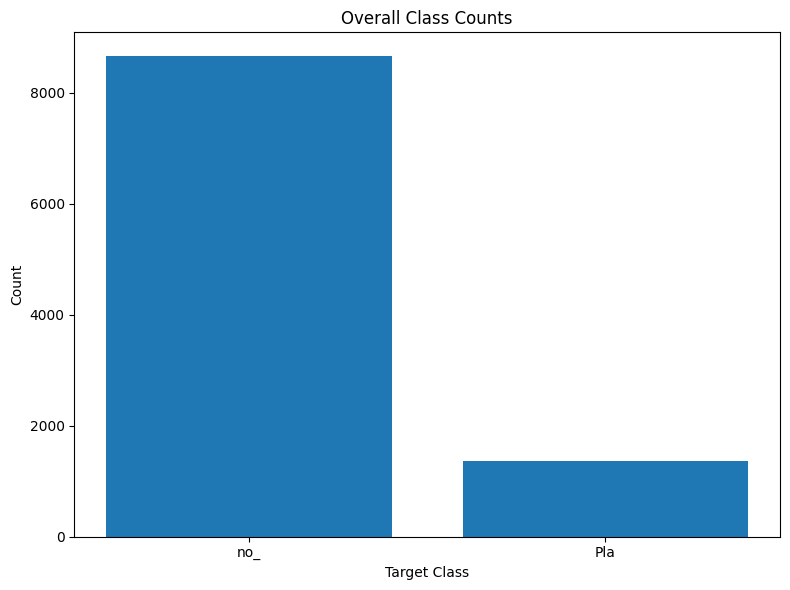

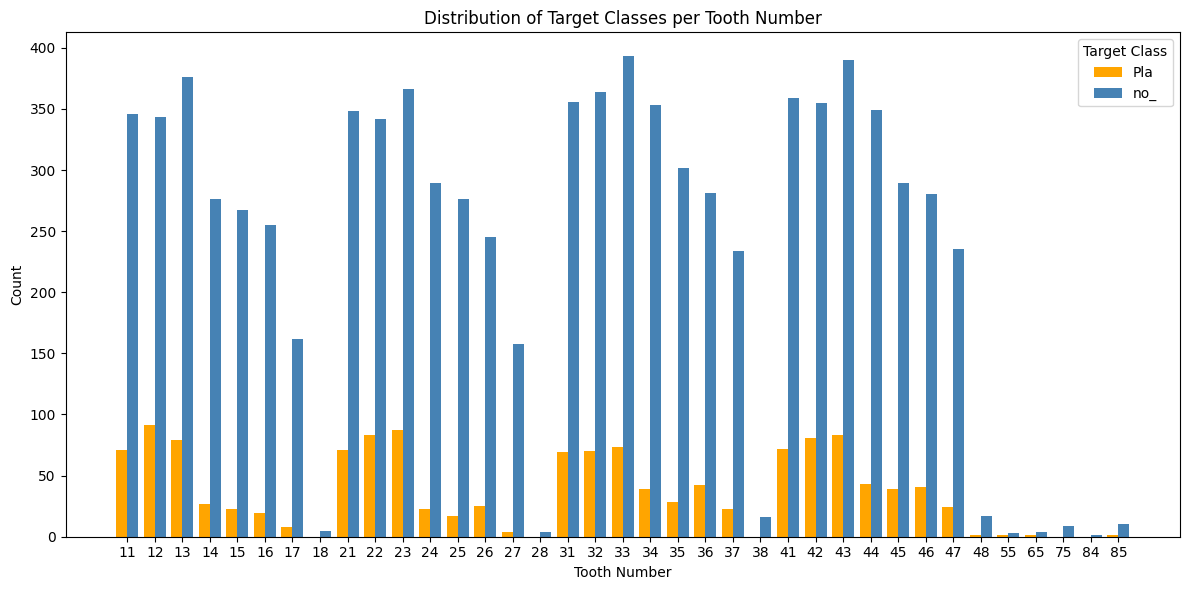

In [134]:
import json
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

# Replace 'data.json' with the path to your JSON file.
with open(path, 'r') as f:
    data = json.load(f)

# Compute overall class counts and distribution per tooth number.
class_counts = Counter()
tooth_class_distribution = defaultdict(Counter)

for record in data.values():
    target_class = record.get('target_class')
    tooth_number = record.get('tooth_number')
    if target_class:
        class_counts[target_class] += 1
        if tooth_number is not None:
            tooth_class_distribution[tooth_number][target_class] += 1

# Figure 1: Bar chart for overall class counts.
plt.figure(figsize=(8, 6))
classes = list(class_counts.keys())
counts = list(class_counts.values())
plt.bar(classes, counts)
plt.title("Overall Class Counts")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Figure 2: Grouped bar chart for distribution of classes per tooth number.
# Prepare the data.
tooth_numbers = sorted(tooth_class_distribution.keys())
# Determine the list of unique classes present.
unique_classes = sorted({cls for counts in tooth_class_distribution.values() for cls in counts})

# Create a dictionary: for each class, a list of counts corresponding to each tooth number.
counts_per_class = {
    cls: [tooth_class_distribution[tooth].get(cls, 0) for tooth in tooth_numbers]
    for cls in unique_classes
}

# Define bar positions.
x = np.arange(len(tooth_numbers))  # positions for tooth numbers
width = 0.8 / len(unique_classes)    # width of each bar (grouped)

plt.figure(figsize=(12, 6))
# Plot bars for each class.
for i, cls in enumerate(unique_classes):
    color = 'orange' if cls == 'Pla' else 'steelblue'  # Example color mapping
    plt.bar(x + i * width, counts_per_class[cls], width=width, label=cls, color=color)

plt.xticks(x + width * (len(unique_classes) - 1) / 2, tooth_numbers)
plt.title("Distribution of Target Classes per Tooth Number")
plt.xlabel("Tooth Number")
plt.ylabel("Count")
plt.legend(title="Target Class")
plt.tight_layout()
plt.show()


# Validation json

In [1]:
path= 'C:/Users/anedaeij23/Project/tooth_classification_project/data/processed/Pla_filtered_val.json'

In [2]:
import json
from collections import Counter, defaultdict

# Replace 'data.json' with the path to your JSON file
with open(path, 'r') as f:
    data = json.load(f)

# Counter for the overall number of each class
class_counts = Counter()

# Dictionary to hold the distribution of classes per tooth number
# Keys are tooth numbers and values are counters of target classes for that tooth
tooth_class_distribution = defaultdict(Counter)

# Iterate over each record in the JSON data
for record in data.values():
    target_class = record.get('target_class')
    tooth_number = record.get('tooth_number')
    
    if target_class:
        class_counts[target_class] += 1
        
        if tooth_number is not None:
            tooth_class_distribution[tooth_number][target_class] += 1

# Print the overall counts for each class
print("Overall class counts:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

# Print the distribution of classes per tooth number
print("\nDistribution of classes in tooth numbers:")
for tooth, counts in sorted(tooth_class_distribution.items()):
    print(f"Tooth number {tooth}: {dict(counts)}")


Overall class counts:
no_: 866
Pla: 136

Distribution of classes in tooth numbers:
Tooth number 11: {'Pla': 10, 'no_': 42}
Tooth number 12: {'no_': 30, 'Pla': 6}
Tooth number 13: {'Pla': 10, 'no_': 34}
Tooth number 14: {'no_': 24, 'Pla': 5}
Tooth number 15: {'no_': 34, 'Pla': 4}
Tooth number 16: {'no_': 24}
Tooth number 17: {'no_': 17, 'Pla': 3}
Tooth number 18: {'no_': 1}
Tooth number 21: {'no_': 42, 'Pla': 7}
Tooth number 22: {'no_': 29, 'Pla': 4}
Tooth number 23: {'no_': 26, 'Pla': 9}
Tooth number 24: {'no_': 31, 'Pla': 3}
Tooth number 25: {'no_': 26, 'Pla': 1}
Tooth number 26: {'no_': 27, 'Pla': 1}
Tooth number 27: {'no_': 9}
Tooth number 31: {'no_': 43, 'Pla': 11}
Tooth number 32: {'no_': 39, 'Pla': 2}
Tooth number 33: {'no_': 45, 'Pla': 2}
Tooth number 34: {'no_': 37, 'Pla': 3}
Tooth number 35: {'Pla': 3, 'no_': 35}
Tooth number 36: {'no_': 25, 'Pla': 5}
Tooth number 37: {'no_': 27, 'Pla': 1}
Tooth number 38: {'no_': 2}
Tooth number 41: {'no_': 29, 'Pla': 8}
Tooth number 42: {'Pl

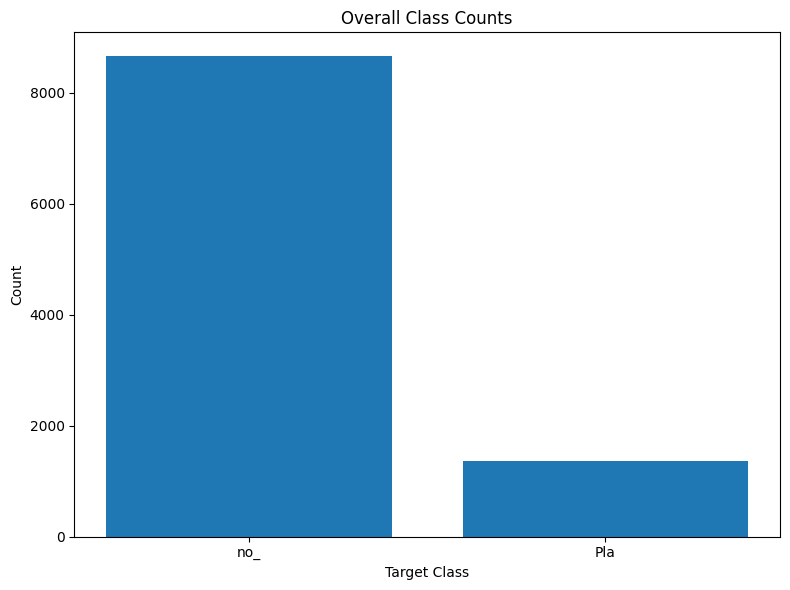

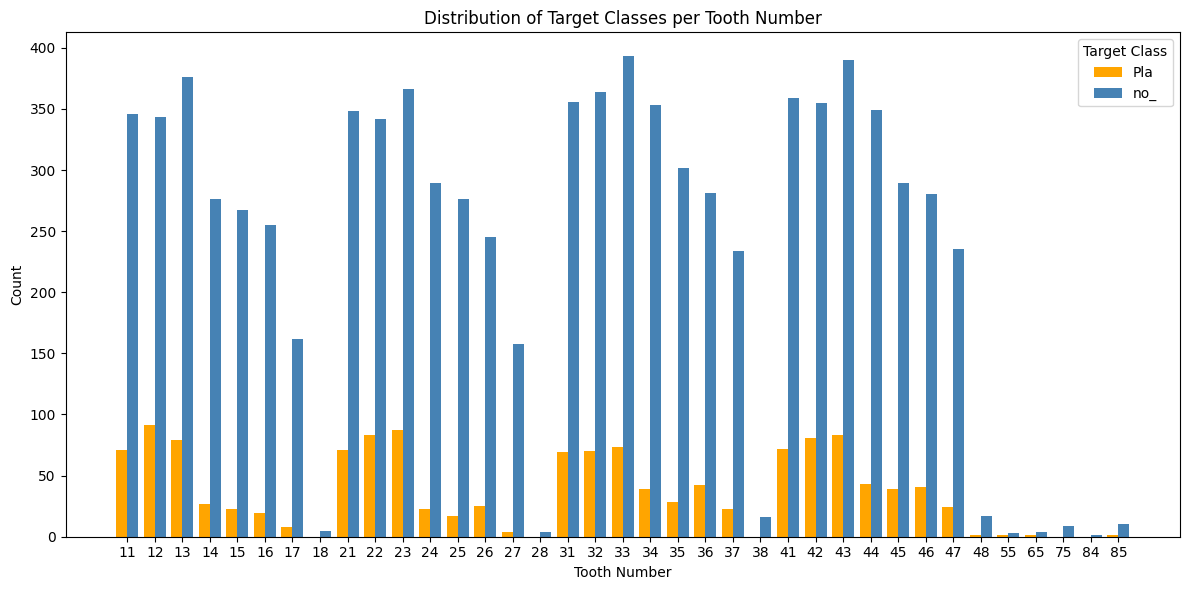

In [129]:
import json
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

# Replace 'data.json' with the path to your JSON file.
with open(path, 'r') as f:
    data = json.load(f)

# Compute overall class counts and distribution per tooth number.
class_counts = Counter()
tooth_class_distribution = defaultdict(Counter)

for record in data.values():
    target_class = record.get('target_class')
    tooth_number = record.get('tooth_number')
    if target_class:
        class_counts[target_class] += 1
        if tooth_number is not None:
            tooth_class_distribution[tooth_number][target_class] += 1

# Figure 1: Bar chart for overall class counts.
plt.figure(figsize=(8, 6))
classes = list(class_counts.keys())
counts = list(class_counts.values())
plt.bar(classes, counts)
plt.title("Overall Class Counts")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Figure 2: Grouped bar chart for distribution of classes per tooth number.
# Prepare the data.
tooth_numbers = sorted(tooth_class_distribution.keys())
# Determine the list of unique classes present.
unique_classes = sorted({cls for counts in tooth_class_distribution.values() for cls in counts})

# Create a dictionary: for each class, a list of counts corresponding to each tooth number.
counts_per_class = {
    cls: [tooth_class_distribution[tooth].get(cls, 0) for tooth in tooth_numbers]
    for cls in unique_classes
}

# Define bar positions.
x = np.arange(len(tooth_numbers))  # positions for tooth numbers
width = 0.8 / len(unique_classes)    # width of each bar (grouped)

plt.figure(figsize=(12, 6))
# Plot bars for each class.
for i, cls in enumerate(unique_classes):
    color = 'orange' if cls == 'Pla' else 'steelblue'  # Example color mapping
    plt.bar(x + i * width, counts_per_class[cls], width=width, label=cls, color=color)

plt.xticks(x + width * (len(unique_classes) - 1) / 2, tooth_numbers)
plt.title("Distribution of Target Classes per Tooth Number")
plt.xlabel("Tooth Number")
plt.ylabel("Count")
plt.legend(title="Target Class")
plt.tight_layout()
plt.show()


# clean blurry images

In [1]:
from skimage import io, color, filters, util
import numpy as np
import os # Optional: if you need to list files in a directory

def calculate_blurriness_skimage(image_path):
    """
    Calculates a blurriness score for an image using the variance of the Laplacian (scikit-image).

    Args:
        image_path (str): The file path to the image.

    Returns:
        float: The variance of the Laplacian. Higher values generally indicate
               sharper images, lower values indicate blurrier images.
               ***IMPORTANT NOTE***: The scale of this variance value will likely be
               MUCH SMALLER than the OpenCV version because scikit-image often works
               with images normalized to the [0, 1] float range. Thresholds will need
               to be adjusted accordingly (e.g., try values << 1.0).
               Returns -1.0 if the image cannot be loaded or processed.
    """
    try:
        # 1. Load the image
        image = io.imread(image_path)

        # Convert image to float format [0, 1] for consistent processing
        # Handles various input types (uint8, uint16, etc.)
        image_float = util.img_as_float(image)

        # 2. Convert to grayscale if it's a color image
        if image_float.ndim == 3:
            # Check for alpha channel (e.g., RGBA in PNGs)
            if image_float.shape[-1] == 4:
                # Convert RGBA to RGB first, then to gray
                gray_image = color.rgb2gray(color.rgba2rgb(image_float))
            elif image_float.shape[-1] == 3:
                 # Convert RGB to gray
                 gray_image = color.rgb2gray(image_float)
            else:
                print(f"Warning: Unexpected number of channels ({image_float.shape[-1]}) for {image_path}")
                return -1.0 # Cannot handle this format
        elif image_float.ndim == 2:
            # It's already grayscale
            gray_image = image_float
        else:
            print(f"Warning: Unexpected image dimensions {image_float.shape} for {image_path}")
            return -1.0 # Cannot handle this format

        # 3. Apply Laplacian filter
        # skimage.filters.laplace returns a numpy array
        laplacian_image = filters.laplace(gray_image)

        # 4. Calculate variance
        variance = np.var(laplacian_image)

        return variance*1000

    except FileNotFoundError:
        print(f"Error: File not found at {image_path}")
        return -1.0
    except Exception as e:
        print(f"Error processing image {image_path} with scikit-image: {e}")
        return -1.0



In [42]:
# 2. Set your parameters
TARGET_DIRECTORY_SK = "C:/Users/anedaeij23\Project/tooth_classification_project/data/raw/REKORHI-front_left-left-465_HmEQGKtZfU.jpg"  # <--- CHANGE THIS
# **VERY IMPORTANT**: The threshold for skimage will be MUCH smaller than OpenCV's.
# Because skimage often works with float images in [0, 1], the variance values are smaller.
# Start testing with very small values like 0.001, 0.0005, or even smaller,
# and adjust based on testing with your specific sharp/blurry images.
BLUR_THRESHOLD_SK = 0.0005  # <--- !! ADJUST THIS SIGNIFICANTLY !!
calculate_blurriness_skimage(TARGET_DIRECTORY_SK)

1.3063567274874868

In [28]:
import pandas as pd
import json
import os   
def create_blurriness_df_from_json(json_path, image_root_dir=None):
    """
    Loads data from a JSON file, calculates the blurriness score for each image,
    and creates a Pandas DataFrame.

    Args:
        json_path (str): The file path to the JSON file. The JSON file should
                         contain a list of dictionaries, where each dictionary has
                         at least 'image_name', 'tooth_number', and 'target_class' keys.
                         The 'image_name' should be the name of the image file.
        image_root_dir (str, optional): The root directory where the image files
                                         are located. If provided, the full image path
                                         will be constructed by joining this directory
                                         with the 'image_name' from the JSON.
                                         If None, it's assumed that the 'image_name'
                                         in the JSON contains the full path to the image.
                                         Defaults to None.

    Returns:
        pandas.DataFrame: A DataFrame with columns 'image_name', 'tooth_number',
                          'target_class', and 'blurriness_score'. Returns an empty
                          DataFrame if the JSON file cannot be loaded or is empty.
    """
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: JSON file not found at {json_path}")
        return pd.DataFrame(columns=['image_name', 'tooth_number', 'target_class', 'blurriness_score'])
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {json_path}")
        return pd.DataFrame(columns=['image_name', 'tooth_number', 'target_class', 'blurriness_score'])

    # if not isinstance(data, list):
    #     print(f"Error: JSON data at {json_path} is not a list of dictionaries.")
    #     return pd.DataFrame(columns=['image_name', 'tooth_number', 'target_class', 'blurriness_score'])

    df_data = []
    for key, record in data.items():
        image_name = record.get('tooth_img_name')
        tooth_number = record.get('tooth_number')
        target_class = record.get('target_class')

        if image_name is None or tooth_number is None or target_class is None:
            print(f"Warning: Missing required keys ('image_name', 'tooth_number', 'target_class') in item: {record}")
            continue

        if image_root_dir:
            image_path = os.path.join(image_root_dir, image_name)
        else:
            image_path = image_name

        blurriness_score = calculate_blurriness_skimage(image_path)
        df_data.append({
            'image_name': image_name,
            'tooth_number': tooth_number,
            'target_class': target_class,
            'blurriness_score': blurriness_score
        })

    df = pd.DataFrame(df_data)
    return df

In [29]:
json_path= 'C:/Users/anedaeij23/Project/tooth_classification_project/data/intrim/filtered_Pla_annotations.json'
image_root_dir = 'C:/Users/anedaeij23/Project/tooth_classification_project/data/raw/'

In [30]:
df_without_root = create_blurriness_df_from_json(json_path, image_root_dir)
print("\nDataFrame without image_root_dir (assuming full paths in JSON):")
print(df_without_root)


DataFrame without image_root_dir (assuming full paths in JSON):
                             image_name  tooth_number target_class  \
0      HONILNO-lower-390_nh1ZWZC_-h.jpg            47          no_   
1      HONILNO-lower-390_dSAFgQIhsC.jpg            46          no_   
2      HONILNO-lower-390_YyKkMc76si.jpg            45          no_   
3      HONILNO-lower-390_wsU7OWGjqT.jpg            44          no_   
4      HONILNO-lower-390_hQ8fP9yWPJ.jpg            43          no_   
...                                 ...           ...          ...   
10012  SIROSVA-upper-359_9ohsG10WWg.jpg            23          Pla   
10013  SIROSVA-upper-359_tIO8I_k30E.jpg            24          no_   
10014  SIROSVA-upper-359_kJPrJl7e7X.jpg            25          no_   
10015  SIROSVA-upper-359_TZTCnDLV8n.jpg            26          no_   
10016  SIROSVA-upper-359_MpA8Pz_Sq1.jpg            27          no_   

       blurriness_score  
0              1.215832  
1              0.699249  
2              0

In [44]:
df_without_root.describe()

,tooth_number,blurriness_score
count,10017.000000,10017.000000
mean,29.349007,0.899564
std,11.693588,1.075361
min,11.000000,0.027524
25%,21.000000,0.263380
50%,31.000000,0.519737
75%,41.000000,1.117302
max,85.000000,13.829547


In [165]:
import json
import pandas as pd
from skimage import io, color, filters, util
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
def plot_blurriness_distribution(df):
    """
    Plots the distribution of blurriness scores based on target class and tooth number.

    Args:
        df (pandas.DataFrame): The DataFrame containing 'target_class', 'tooth_number',
                               'blurriness_score'.
    """
    if df.empty:
        print("Warning: Input DataFrame is empty. No plots will be generated.")
        return

    # Distribution of blurriness score by target class
    plt.figure(figsize=(10, 6))
    color_palette = {'Pla': 'orange', 'no_': 'steelblue'}
    sns.boxplot(x='target_class', y='blurriness_score', data=df, palette=color_palette)
    plt.title('Blurriness Score Distribution by Target Class')
    plt.xlabel('Target Class')
    plt.ylabel('Blurriness Score')
    plt.grid(True)
    plt.show()

    # Distribution of blurriness score by tooth number
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='tooth_number', y='blurriness_score', data=df)
    plt.title('Blurriness Score Distribution by Tooth Number')
    plt.xlabel('Tooth Number')
    plt.ylabel('Blurriness Score')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Optional: Violin plots for a different view of the distribution
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='target_class', y='blurriness_score', data=df)
    plt.title('Violin Plot of Blurriness Score by Target Class')
    plt.xlabel('Target Class')
    plt.ylabel('Blurriness Score')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.violinplot(x='tooth_number', y='blurriness_score', data=df)
    plt.title('Violin Plot of Blurriness Score by Tooth Number')
    plt.xlabel('Tooth Number')
    plt.ylabel('Blurriness Score')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # # Optional: Scatter plot of blurriness vs. tooth number, colored by target class
    # plt.figure(figsize=(14, 7))
    # sns.scatterplot(x='tooth_number', y='blurriness_score', hue='target_class', data=df)
    # plt.title('Blurriness Score vs. Tooth Number, Colored by Target Class')
    # plt.xlabel('Tooth Number')
    # plt.ylabel('Blurriness Score')
    # plt.xticks(rotation=45, minor=True ,ticks=np.arange(10, 87, step=1), labels=np.arange(10, 87, step=1)) # Rotate x-axis labels for better readability
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()
    
    # Scatter plot of blurriness vs. tooth number, colored by target class with colored x-axis labels
    def get_tooth_set(tooth_number):
        try:
            tooth = int(tooth_number)
            if 10 <= tooth <= 19:
                return '1x'
            elif 20 <= tooth <= 29:
                return '2x'
            elif 30 <= tooth <= 39:
                return '3x'
            elif 40 <= tooth <= 49:
                return '4x'
            elif 50 <= tooth <= 59:
                return '5x'
            elif 60 <= tooth <= 69:
                return '6x'
            elif 70 <= tooth <= 79: # Assuming up to 66 for demonstration, adjust as needed
                return '7x'
            elif 80 <= tooth <= 89: # Assuming up to 66 for demonstration, adjust as needed
                return '8x'
            else:
                return 'Other'
        except ValueError:
            return 'Invalid'

    df['tooth_set'] = df['tooth_number'].apply(get_tooth_set)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='tooth_number', y='blurriness_score', hue='target_class', data=df)
    plt.title('Blurriness Score vs. Tooth Number, Colored by Target Class')
    plt.xlabel('Tooth Number')
    plt.ylabel('Blurriness Score')
    plt.xticks(sorted(df['tooth_number'].unique()), rotation=90, ha='center', minor=False)
    plt.yscale('log')  # Log scale for better visibility of blurriness scores
    plt.yticks(minor= True)
    plt.grid(True)
    plt.tight_layout()

    # Define colors for each tooth set for the x-axis labels
    tooth_set_colors = {
        '1x': 'red',
        '2x': 'blue',
        '3x': 'green',
        '4x': 'purple',
        '5x': 'orange',
        '6x': 'brown',
        '7x': 'pink',
        '8x': 'gray',
        'Other': 'cyan',
        'Invalid': 'black'
    }

    # Get the current x-axis tick labels
    ax = plt.gca()
    xticks_labels = ax.get_xticklabels()
    xticks_locations = ax.get_xticks()

    # Iterate through the labels and set their color based on the tooth set
    for label, tick_location in zip(xticks_labels, xticks_locations):
        tooth_number = label.get_text()
        tooth_set = get_tooth_set(tooth_number)
        if tooth_set in tooth_set_colors:
            label.set_color(tooth_set_colors[tooth_set])
            
    # Add horizontal lines and labels for "Pla" class
    pla_df = df[df['target_class'] == 'Pla']
    y_values = [0.2, 0.3, 0.4, 0.5, 0.6]
    pla_counts = len(pla_df)
    for y_val in y_values:
        count_below = pla_df[pla_df['blurriness_score'] < y_val].shape[0]
        plt.axhline(y=y_val, color='darkred', linestyle='--', linewidth=1)
        plt.text(55, y_val, f'Pla < {y_val}: {100*count_below/pla_counts:.1f}%', verticalalignment='bottom')

    plt.show()

C:\Users\anedaeij23\AppData\Local\Temp\ipykernel_13248\500430275.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_class', y='blurriness_score', data=df, palette=color_palette)


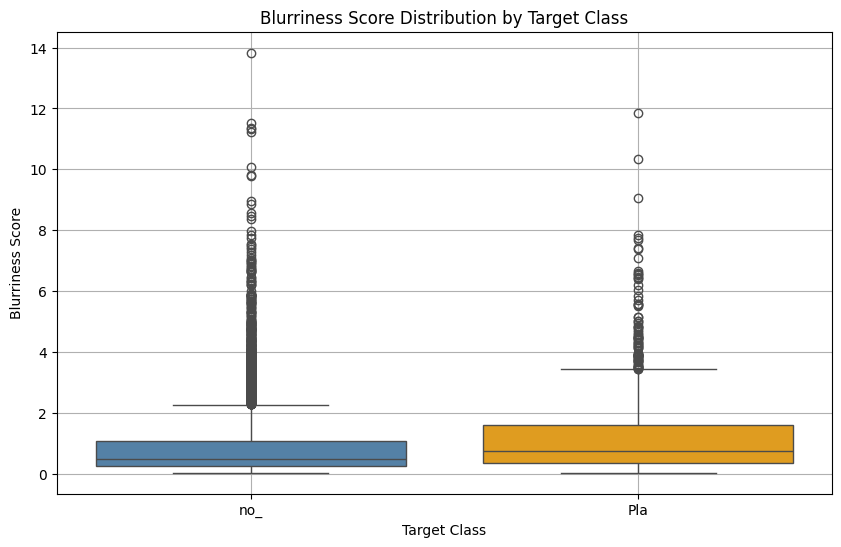

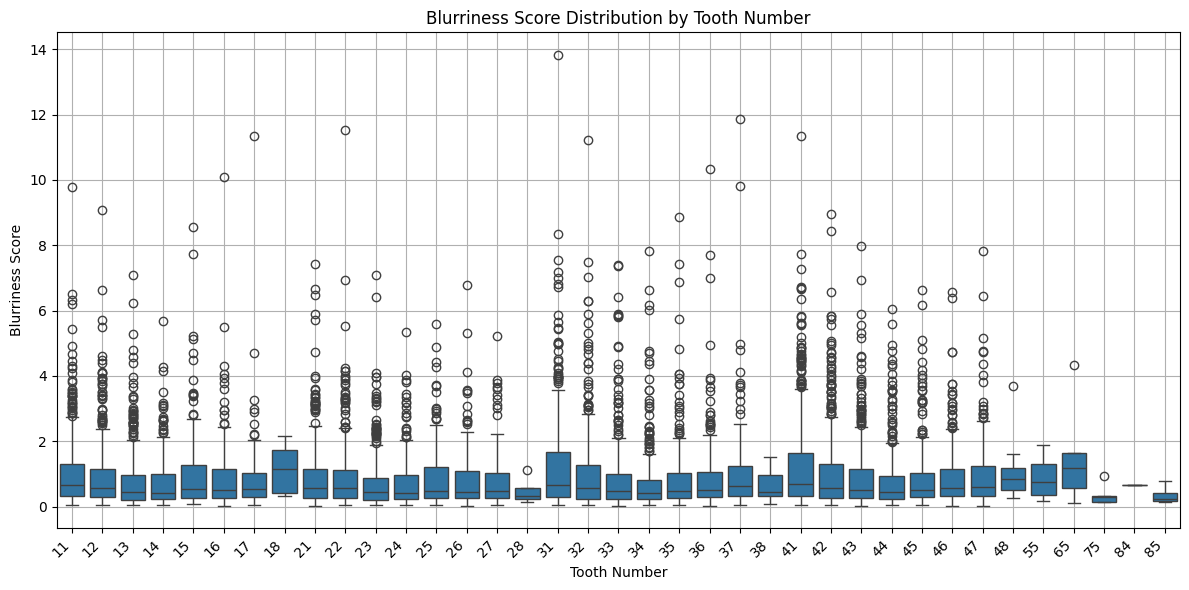

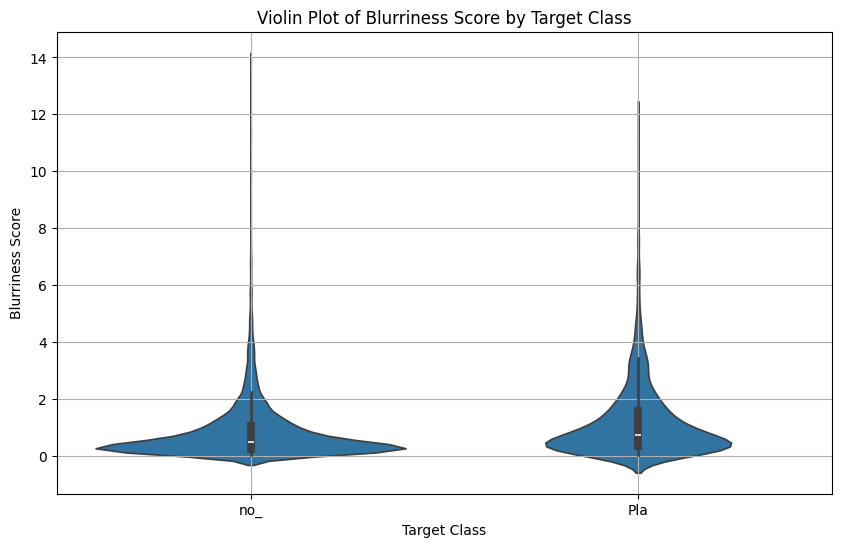

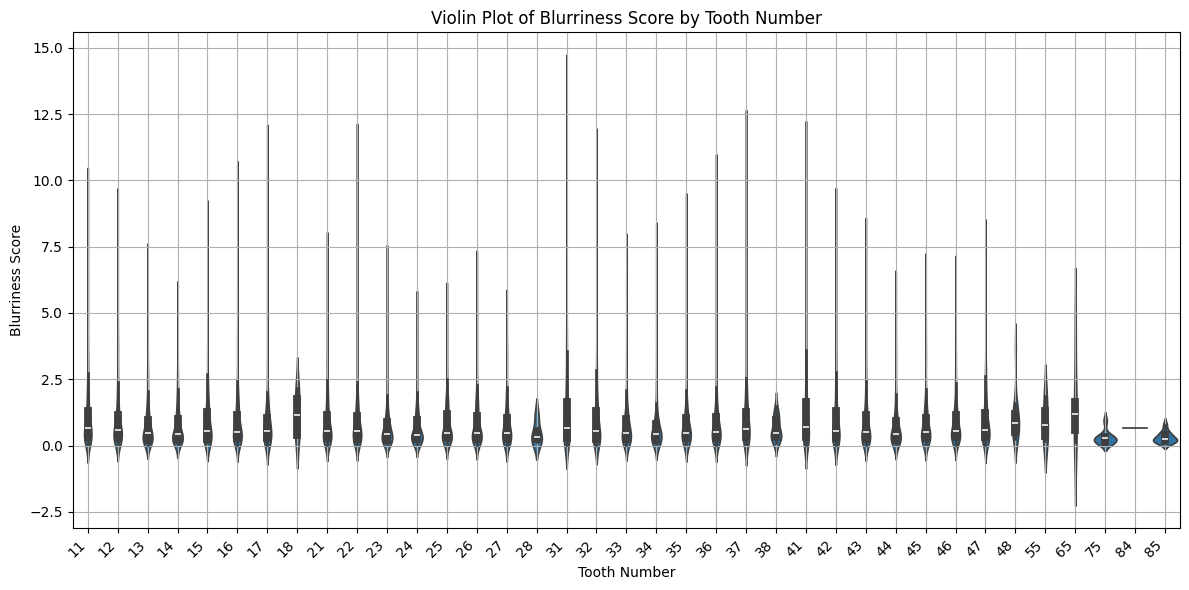

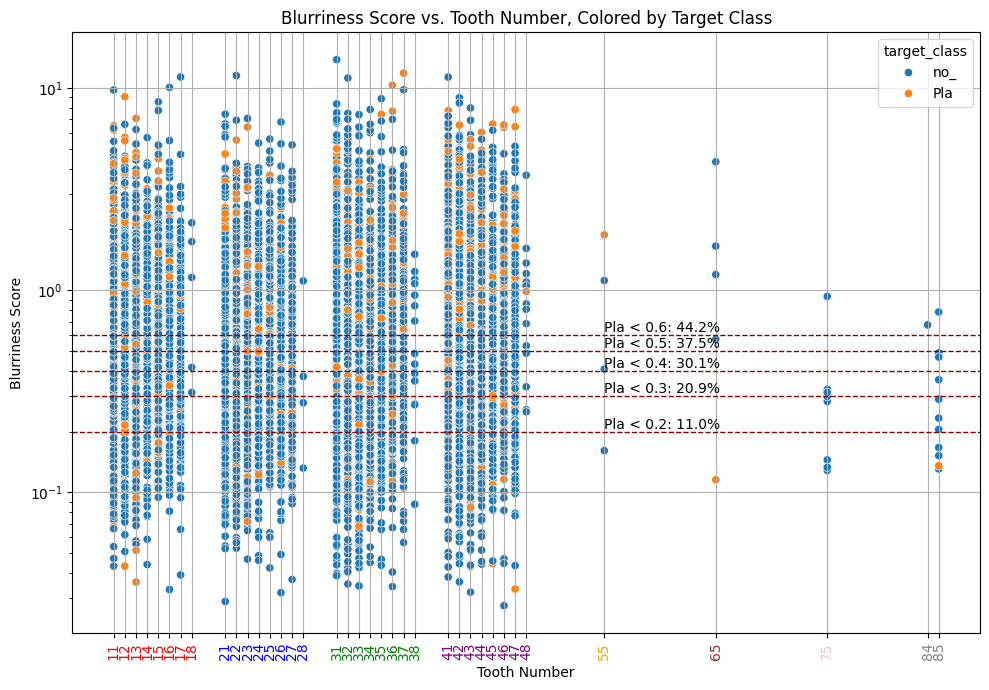

In [166]:
plot_blurriness_distribution(df_without_root)

In [112]:
pla_df = df_without_root[df_without_root['target_class'] == 'Pla']


In [115]:
x_df = df_without_root[df_without_root['target_class'] == 'no_']

In [116]:
x_df[['image_name', 'blurriness_score']][x_df['blurriness_score'] < 0.3]

,image_name,blurriness_score
7,HONILNO-lower-390_BbZ0na_f4l.jpg,0.265721
8,HONILNO-lower-390_NGa2LBsa7J.jpg,0.140692
9,HONILNO-lower-390_7TBC9hYsKi.jpg,0.288323
13,HONILNO-upper-390_At2XSqs08t.jpg,0.132975
14,HONILNO-upper-390_TmlmQMSQU_.jpg,0.158557
...,...,...
9897,TOPAHNI-upper-134_8iZsh5cywq.jpg,0.135589
9898,TOPAHNI-upper-134_8gTJANXIcx.jpg,0.115056
9899,TOPAHNI-upper-134_v3CrABX2Xu.jpg,0.144732
9925,POJENMU-lower-7_7vgCcuvRJL.jpg,0.263708


In [121]:
pla_df[['image_name', 'blurriness_score']][pla_df['tooth_number'] == 48]

,image_name,blurriness_score
5213,HUSIKJI-lower-166_E4f1e1e9ZL.jpg,0.986029


In [ ]:
# --- How to use it in your data cleaning process (Example) ---

# The cleaning function structure remains the same, just call the skimage version

def clean_blurry_images_skimage(image_directory, blur_threshold, action='print'):
    """
    Iterates through images using the scikit-image blur detection method.

    Args:
        image_directory (str): Path to the directory containing images.
        blur_threshold (float): Images with a blurriness score BELOW this value
                                will be considered blurry. **NOTE: This threshold
                                needs to be much smaller than for the OpenCV version!**
        action (str): 'print', 'delete', 'move'. Defaults to 'print'.
    """
    blurry_files = []
    if action == 'move':
        blurry_folder = os.path.join(image_directory, "blurry_images_skimage")
        os.makedirs(blurry_folder, exist_ok=True)
        print(f"Blurry images will be moved to: {blurry_folder}")

    print(f"Scanning directory: {image_directory} (using scikit-image)")
    print(f"Using blur threshold: {blur_threshold} (Note: skimage scale differs from OpenCV)")

    for filename in os.listdir(image_directory):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif', '.webp')):
            image_path = os.path.join(image_directory, filename)

            if os.path.isfile(image_path):
                # *** Use the skimage version of the function ***
                blur_score = calculate_blurriness_skimage(image_path)

                if blur_score == -1.0: # Image loading/processing failed
                    continue

                # print(f"Image: {filename}, Blur Score (skimage): {blur_score:.6f}") # Debugging

                if blur_score < blur_threshold:
                    blurry_files.append(filename)
                    print(f"Detected blurry image: {filename} (Score: {blur_score:.6f})") # Use more decimal places

                    if action == 'delete':
                        try:
                            os.remove(image_path)
                            print(f"  - Deleted: {filename}")
                        except Exception as e:
                            print(f"  - Error deleting {filename}: {e}")
                    elif action == 'move':
                        try:
                            destination_path = os.path.join(blurry_folder, filename)
                            os.rename(image_path, destination_path)
                            print(f"  - Moved: {filename} to {blurry_folder}")
                        except Exception as e:
                            print(f"  - Error moving {filename}: {e}")

    print(f"\nFinished scanning. Found {len(blurry_files)} potentially blurry images.")
    return blurry_files




In [ ]:
# --- Example Usage ---

# 1. Installation (if you haven't already)
# pip install scikit-image numpy matplotlib # matplotlib is often useful with skimage for display

# 2. Set your parameters
TARGET_DIRECTORY_SK = "/path/to/your/images"  # <--- CHANGE THIS
# **VERY IMPORTANT**: The threshold for skimage will be MUCH smaller than OpenCV's.
# Because skimage often works with float images in [0, 1], the variance values are smaller.
# Start testing with very small values like 0.001, 0.0005, or even smaller,
# and adjust based on testing with your specific sharp/blurry images.
BLUR_THRESHOLD_SK = 0.0005  # <--- !! ADJUST THIS SIGNIFICANTLY !!

# 3. Run the cleaning process
potentially_blurry_sk = clean_blurry_images_skimage(TARGET_DIRECTORY_SK, BLUR_THRESHOLD_SK, action='print')

# print("\nList of potentially blurry files (skimage):")
# for f in potentially_blurry_sk:
#     print(f)0